# **PRACTICA N° 3: ANALISIS ESTADISTICO DE SEÑALES**

Juan Esteban Hincapie Cardona

Estefania Loaiza Salgado

**Primera parte ECG**

In [5]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.io import loadmat 
import pandas as pd
print('Exito')

Exito


1. Implemente una función que permita calcular el valor cuadrático medio (RMS) de una señal. El valor RMS se define en forma discreta con N número de muestras, como:
Formula 

In [6]:
def RMS(x):
    return np.sqrt(np.mean(x**2)) 

**Señal Electrocardiográfica (ECG)**

El electrocardiograma es el registro de la actividad eléctrica del corazón medida a través de electrodos colocados sobre la piel. Esta señal refleja los procesos de despolarización y repolarización de las células cardíacas durante cada latido.

Un ciclo cardíaco típico está compuesto por:

Onda P: despolarización auricular
Complejo QRS: despolarización ventricular
Onda T: repolarización ventricular

Las frecuencias de interés de una señal ECG generalmente se encuentran aproximadamente entre:

0.5 Hz y 40 Hz

Por esta razón, los sistemas de adquisición de ECG suelen utilizar filtros pasa banda que eliminan:

Ruido de baja frecuencia (movimiento del paciente, deriva de línea base)
Ruido de alta frecuencia (interferencia eléctrica o muscular)
Frecuencia de muestreo y duración de la señal

La duración total de una señal digital se calcula como:

𝑇= 𝑁/𝐹𝑠

donde:
N = número total de muestras
𝐹s = frecuencia de muestreo

En este caso:
N = 30720 muestras
Fs = 1024 Hz

Por lo tanto:

**Duración de la señal:**

𝑇 = 30720/1024 = 30s

La señal tiene una duración total de 30 segundos.

El vector de tiempo se crea como:

𝑡 = 0 : 1/𝐹𝑠 : 𝑇

**Parámetros estadísticos**

Para analizar una señal en el dominio del tiempo se utilizan diferentes medidas estadísticas.

* **Promedio**

Representa el valor medio de la señal.

𝜇 = 1/𝑁 ∑𝑥𝑖

* **Valor RMS (Root Mean Square)**

Indica el valor eficaz de la señal.

* **Varianza**

Mide qué tan dispersos están los datos respecto al promedio.

* **Desviación estándar**

Es la raíz cuadrada de la varianza.
	​


In [8]:
#cargar archivo .mat
data = loadmat('signals.mat')
print(data.keys()) #imprime las claves del diccionario cargado

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


1. A partir de la información suministrada en el archivo .mat, determine el tiempo de duración de las
señales, cree un vector de tiempo.

In [11]:
Fs = data['Fs'][0][0]   # frecuencia de muestreo

ecg = data['ECG_asRecording'].squeeze()
ecg_filtrada = data['ECG_filtered'].squeeze()

N = len(ecg)            # número de muestras
duracion = N / Fs       # duración de la señal

print("Número de muestras:", N)
print("Frecuencia de muestreo:", Fs)
print("Duración:", duracion, "segundos")

# Vector de tiempo
t = np.arange(0, N) / Fs
print(len(t))

Número de muestras: 30720
Frecuencia de muestreo: 1024
Duración: 30.0 segundos
30720


2. Grafique la señal sin filtrar y filtrada, compárelas. Comente lo que observa, y describa cómo debe ser
el comportamiento del filtro que se utilizó. Recuerde las frecuencias de interés de la señal ECG.

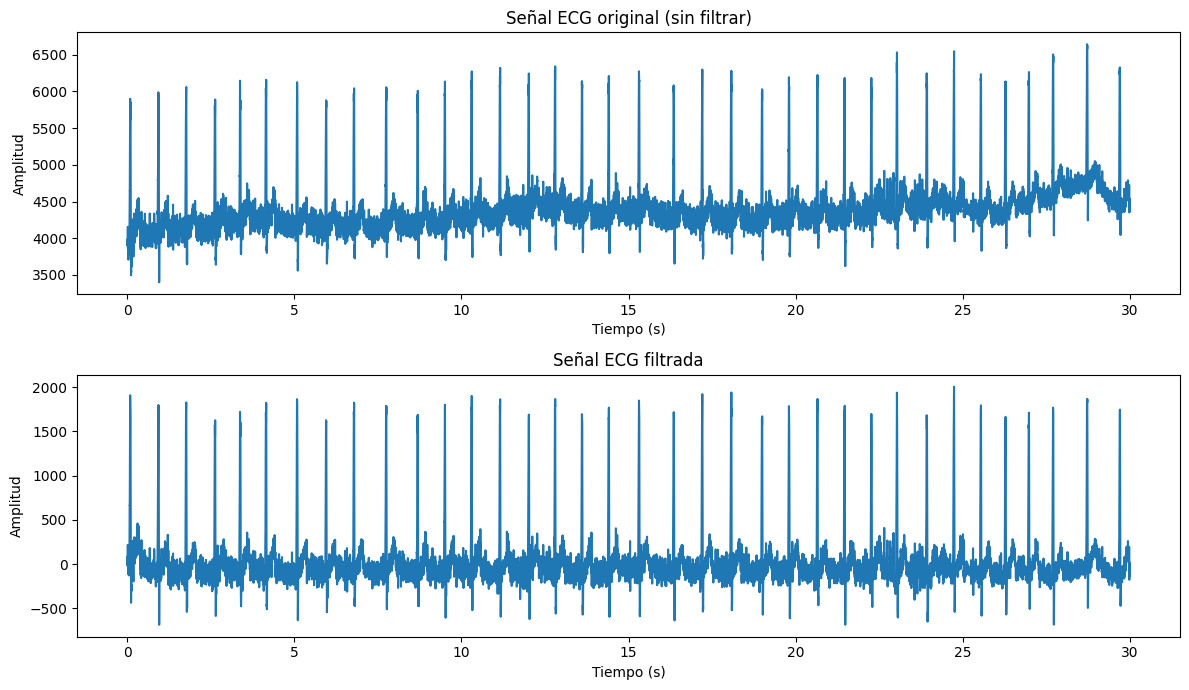

In [21]:
plt.figure(figsize=(12,7))

plt.subplot(2,1,1)
plt.plot(t, ecg)
plt.title("Señal ECG original (sin filtrar)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.subplot(2,1,2)
plt.plot(t, ecg_filtrada)
plt.title("Señal ECG filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.tight_layout()
plt.show()

como en las graficas anteriores no se logra visualizar alguna diferencia, se decidio hacer un tipo de "zoom" 

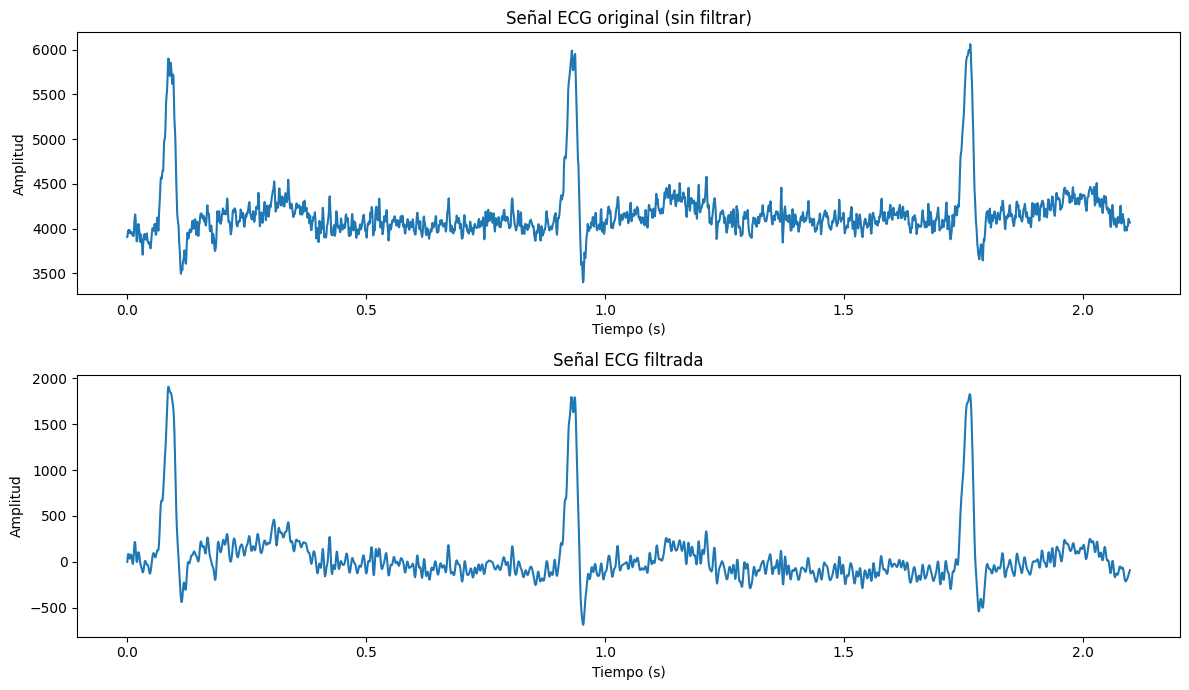

In [30]:
plt.figure(figsize=(12,7))

plt.subplot(2,1,1)
plt.plot(t[0:2150], ecg[0:2150])
plt.title("Señal ECG original (sin filtrar)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.subplot(2,1,2)
plt.plot(t[0:2150], ecg_filtrada[0:2150])
plt.title("Señal ECG filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.tight_layout()
plt.show()

nota: se puede notar una reduccion  de la cantidad de picos por cada segmento analizado. Se logra percibir como una suavidad al analizar los picos de las ondas R, donde parece haberse aplicado un filtro pasa bajas, seguido de un filtro pasaaltas. Para solo dejar las frecuencias del EKG de interes, frecuencias anteriormente descritas.

3. Tome la señal tal cual se registró. De dicha señal, seleccione un ciclo cardiaco, grafique. Calcule el
promedio, el valor RMS, la varianza y la desviación estándar del ciclo. Analice los resultados.

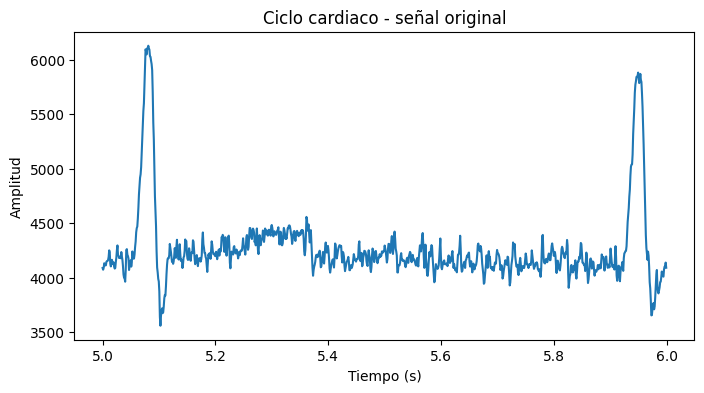

In [40]:
# Seleccionar un ciclo cardiaco (1 segundo aprox)
inicio = int(5 * Fs)       # segundo 5
fin = int(6 * Fs)          # segundo 6


# fin = int(1 * Fs)          # segundo 6
# inicio = int(2 * Fs)       # segundo 5


ciclo = ecg[inicio:fin]
t_ciclo = t[inicio:fin]

plt.figure(figsize=(8,4))
plt.plot(t_ciclo, ciclo)
plt.title("Ciclo cardiaco - señal original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

In [41]:
# Promedio
promedio = np.mean(ciclo)

# RMS
rms = RMS(ciclo)

# Varianza
varianza = np.var(ciclo)

# Desviación estándar
desviacion = np.std(ciclo)

print("Resultados señal original:")
print("Promedio:", promedio)
print("RMS:", rms)
print("Varianza:", varianza)
print("Desviación estándar:", desviacion)

Resultados señal original:
Promedio: 4264.613161563873
RMS: 4279.476775286304
Varianza: 126996.05243104555
Desviación estándar: 356.3650550082675


4. Tome la señal filtrada. Repita el procedimiento anterior con esta señal, compare con los resultados
obtenidos en el ítem anterior.

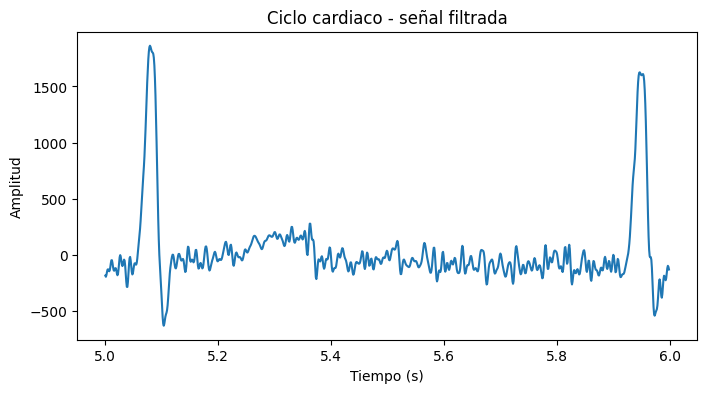

In [42]:
# Seleccionar el mismo ciclo pero de la señal filtrada
ciclo_filtrado = ecg_filtrada[inicio:fin]

plt.figure(figsize=(8,4))
plt.plot(t_ciclo, ciclo_filtrado)
plt.title("Ciclo cardiaco - señal filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

In [43]:
promedio_f = np.mean(ciclo_filtrado)

rms_f = RMS(ciclo_filtrado)

varianza_f = np.var(ciclo_filtrado)

desviacion_f = np.std(ciclo_filtrado)

print("Resultados señal filtrada:")
print("Promedio:", promedio_f)
print("RMS:", rms_f)
print("Varianza:", varianza_f)
print("Desviación estándar:", desviacion_f)

Resultados señal filtrada:
Promedio: 23.15180801596328
RMS: 353.55848710125093
Varianza: 124467.59758691741
Desviación estándar: 352.7996564438767


------ COMPARACIÓN ------
Promedio original: 4264.613161563873
Promedio filtrado: 23.15180801596328
RMS original: 4279.476775286304
RMS filtrado: 353.55848710125093
Varianza original: 126996.05243104555
Varianza filtrada: 124467.59758691741
Desviación original: 356.3650550082675
Desviación filtrada: 352.7996564438767


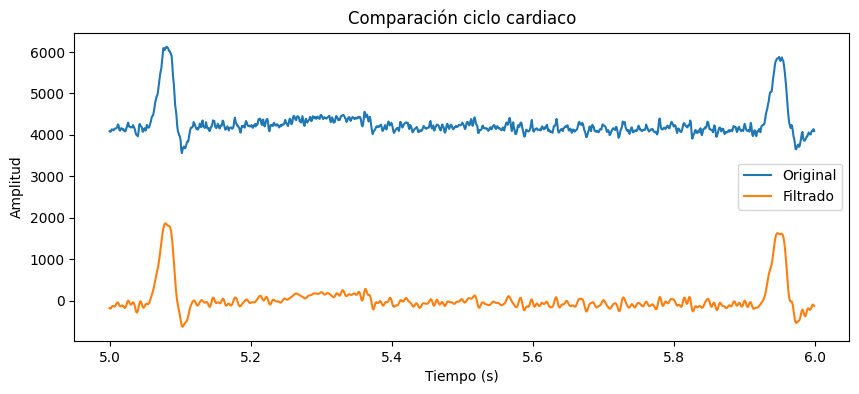

In [44]:
print("------ COMPARACIÓN ------")

print("Promedio original:", promedio)
print("Promedio filtrado:", promedio_f)

print("RMS original:", rms)
print("RMS filtrado:", rms_f)

print("Varianza original:", varianza)
print("Varianza filtrada:", varianza_f)

print("Desviación original:", desviacion)
print("Desviación filtrada:", desviacion_f)

plt.figure(figsize=(10,4))

plt.plot(t_ciclo, ciclo, label="Original")
plt.plot(t_ciclo, ciclo_filtrado, label="Filtrado")

plt.title("Comparación ciclo cardiaco")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()

plt.show()

El resultado más relevante fue observar que el filtrado reduce significativamente el ruido presente en la señal original, permitiendo visualizar con mayor claridad las características del ciclo cardíaco (ondas P, complejo QRS y onda T).

5. Extraiga 15 ciclos de la señal filtrada, y para cada ciclo calcule el valor promedio y la varianza, grafique
cada ciclo, y analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria?

          ciclo   promedio      varianza  \
0         0-819  92.613982  97104.796606   
1      819-1638  -5.759178  90783.766936   
2     1638-2457  -5.569453    86514.4258   
3     2457-3276  -9.398469   76845.82085   
4     3276-4096  16.447868  77665.430724   
5     4096-4915  -0.953211  88959.169706   
6     4915-5734  10.228219  90112.314422   
7     5734-6553   1.299228  74940.732783   
8     6553-7372  12.815242  85854.369742   
9     7372-8192  -2.842377  85858.195211   
10    8192-9011 -11.624461  75141.468021   
11    9011-9830  -6.169956  83305.230833   
12   9830-10649   13.10295  91311.495758   
13  10649-11468  -2.367709  94280.639861   
14  11468-12288 -45.526944  16094.876896   

                                               tiempo  \
0   [0.0, 0.0009765625, 0.001953125, 0.0029296875,...   
1   [0.7998046875, 0.80078125, 0.8017578125, 0.802...   
2   [1.599609375, 1.6005859375, 1.6015625, 1.60253...   
3   [2.3994140625, 2.400390625, 2.4013671875, 2.40...   
4   [3.199

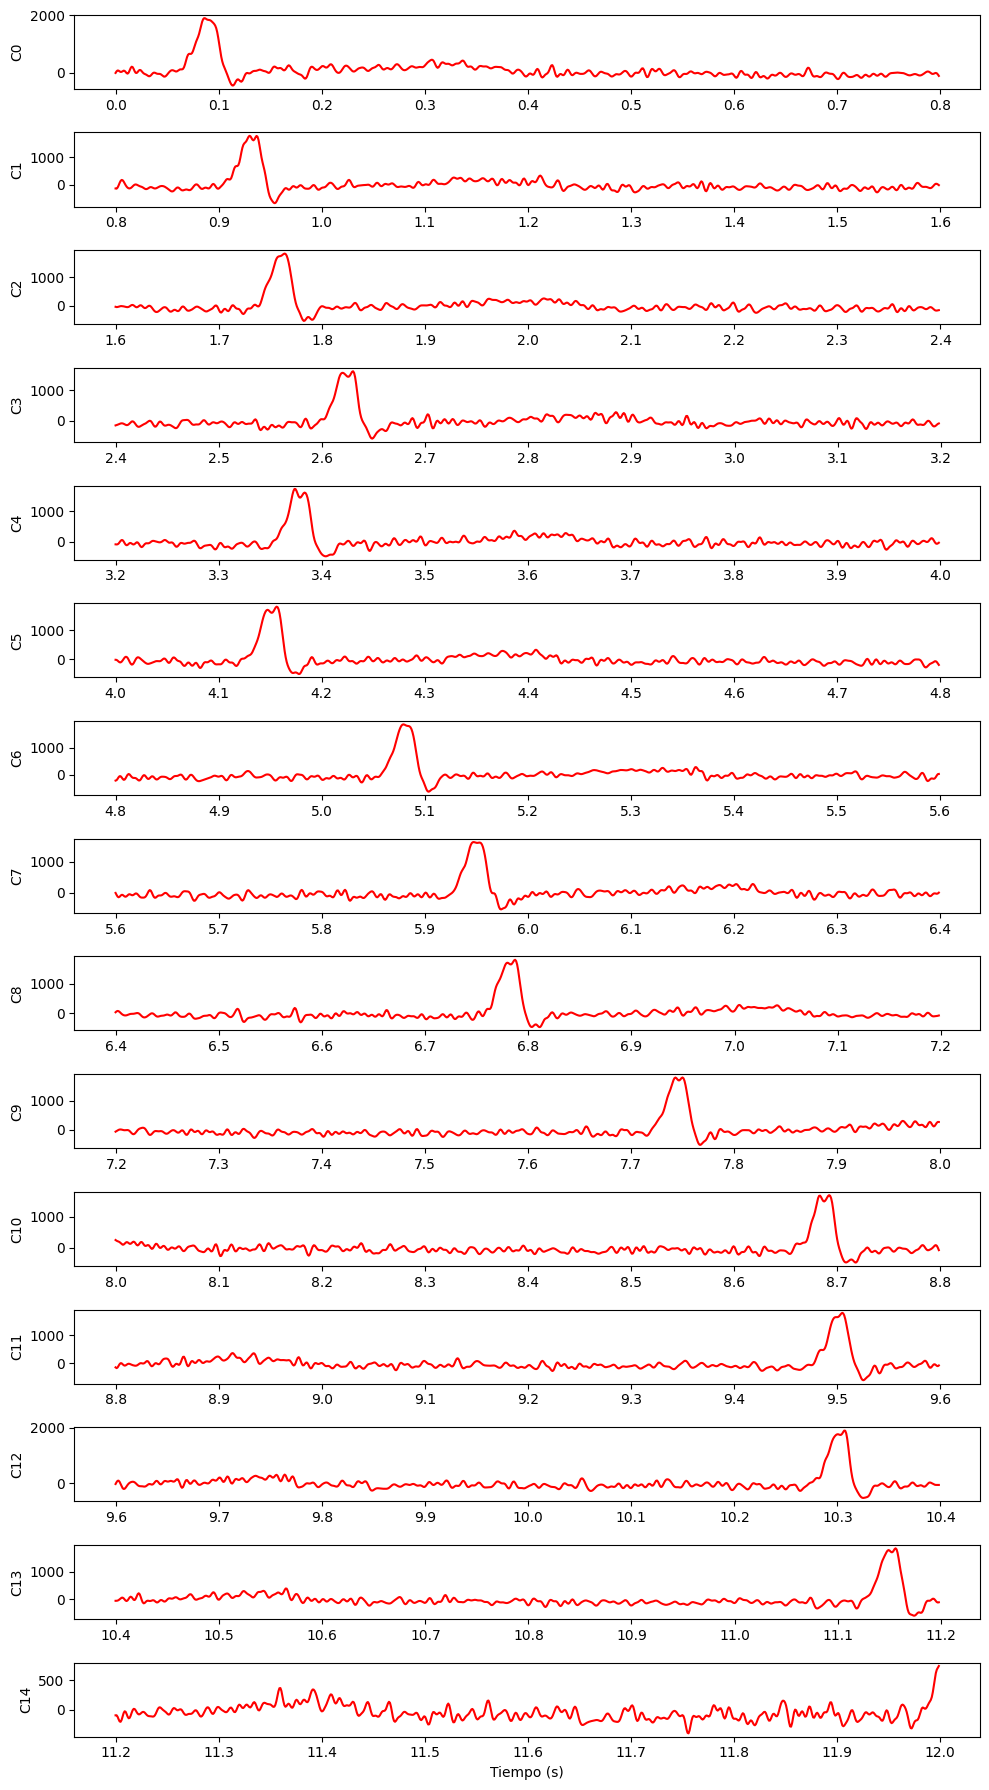

In [78]:
infoCiclos = pd.DataFrame(columns=["ciclo","promedio","varianza", "tiempo", "valores"])

for n in range(15):
    
    inicio = int(n*0.8 * Fs)
    fin = int((n*0.8 + 0.8) * Fs)

    ciclo = ecg_filtrada[inicio:fin]
    t_ciclo = t[inicio:fin]

    promedio = np.mean(ciclo)
    varianza = np.var(ciclo)

    Nciclo = f"{inicio}-{fin}"

    nuevaFila = {
        "ciclo": Nciclo,
        "promedio": promedio,
        "varianza": varianza,
        "tiempo": t_ciclo,
        "valores": ciclo
    }

    infoCiclos = pd.concat([infoCiclos, pd.DataFrame([nuevaFila])], ignore_index=True)

print(infoCiclos)

plt.figure(figsize=(10,18))

for n in range(15):
    plt.subplot(15,1,n+1)
    plt.plot(infoCiclos["tiempo"][n], infoCiclos["valores"][n], color = "r")
    plt.ylabel(f"C{n}")

plt.xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()



Anteriormente se selecciono que la duracion de un cliclo cardiaco era de 1 segundo. Al revisar la literatura se encontro que un ciclo esta alrededor de 75 bpm lo que se traduce que cada ciclo dura aproximadamente 0.8 segundos [3] en codiciones fisiologicas normales y en reposo.
Al analizar los 15 ciclos de la señal ECG filtrada, se observa que la morfología general se mantiene, evidenciando la presencia consistente del complejo QRS en cada segmento. Sin embargo, existen variaciones en la amplitud de los picos y en los valores de la señal, lo que indica que la varianza no se mantiene constante a lo largo del tiempo. Por tanto, la señal no puede considerarse estrictamente estacionaria, aunque presenta características de estacionariedad local en intervalos cortos.

In [ ]:
media_promedios = np.mean(infoCiclos["promedio"])
std_promedios = np.std(infoCiclos["promedio"])

media_varianzas = np.mean(infoCiclos["varianza"])
std_varianzas = np.std(infoCiclos["varianza"])

print("Media de promedios:", media_promedios)
print("STD de promedios:", std_promedios)

print("Media de varianzas:", media_varianzas)
print("STD de varianzas:", std_varianzas)

Media de promedios: 3.7530486248804635
STD de promedios: 27.67891442525186
Media de varianzas: 80984.84894323614
STD de varianzas: 18581.61591057423


El análisis estadístico de los ciclos muestra que la desviación estándar de los promedios (27.68) es considerablemente mayor que el valor promedio (3.75), lo que indica una alta variabilidad en la media entre ciclos. Asimismo, la varianza presenta un coeficiente de variación aproximado del 23%, evidenciando que no se mantiene constante en el tiempo. Estos resultados indican que la señal no cumple con las condiciones de estacionariedad, ya que tanto la media como la varianza presentan variaciones significativas entre ciclos.

6. Realice dos veces comparaciones entre dos ciclos cualquiera utilizando una prueba t. Determine
estadísticamente si existe diferencia estadística entre los ciclos, Compruebe los supuestos necesarios
para realizar una prueba t, esto es: Normalidad de la variable, independencia (se asume que los grupos
son independientes), y homocedasticidad (use una prueba de Levene), finalmente realice la prueba t
para determinar si existen diferencias entre los ciclos. Qué indica este análisis respecto de la
estacionariedad, explique. De no cumplirse los requisitos, realice entonces un análisis no paramétrico
(prueba U de Mann-Whitney).

Se seleccionaron dos ciclos representativos de la señal, asegurando que contienen un latido completo y presentan morfología similar, con el fin de realizar una comparación estadística válida. C1 y C5


In [80]:
# Extraer ciclos C1 y C5
ciclo1 = infoCiclos["valores"][1]
ciclo5 = infoCiclos["valores"][5]

print(len(ciclo1), len(ciclo5))

from scipy.stats import shapiro

stat1, p1 = shapiro(ciclo1)
stat5, p5 = shapiro(ciclo5)

print("Ciclo 1 p-value:", p1)
print("Ciclo 5 p-value:", p5)    

# p > 0.05 → distribución normal
# p < 0.05 → no normal

819 819
Ciclo 1 p-value: 1.3012301138176934e-40
Ciclo 5 p-value: 1.8056246781230852e-41


Ambos p-values son muchísimo menores que 0.05, por lo que se rechaza la hipótesis de normalidad en los dos ciclos.
En consecuencia, los datos no siguen una distribución normal y el supuesto de normalidad para el test t no se cumple.

Dado que los datos no cumplen el supuesto de normalidad (p < 0.05 en la prueba de Shapiro-Wilk), se optó por utilizar una prueba no paramétrica (Mann-Whitney U) para comparar los ciclos seleccionados. 

In [81]:
from scipy.stats import mannwhitneyu

# Prueba Mann-Whitney U
stat, p = mannwhitneyu(ciclo1, ciclo5, alternative='two-sided')

print("Estadístico U:", stat)
print("p-value:", p)

if p < 0.05:
    print("Se rechaza H0 → los ciclos provienen de distribuciones diferentes")
else:
    print("No se rechaza H0 → no hay evidencia de diferencia entre ciclos")

Estadístico U: 326918.0
p-value: 0.37665445768971273
No se rechaza H0 → no hay evidencia de diferencia entre ciclos


La prueba no paramétrica de Mann-Whitney aplicada a los ciclos C1 y C5 arrojó un p-value de 0.3767, mayor al nivel de significancia de 0.05. Por lo tanto, no se rechaza la hipótesis nula, indicando que no existen diferencias estadísticamente significativas entre las distribuciones de ambos ciclos. Esto sugiere que, de manera local, la señal presenta comportamiento aproximadamente estacionario.
Sin embargo, este resultado no es suficiente para concluir que la señal es completamente estacionaria, ya que otras comparaciones entre ciclos pueden mostrar diferencias.

In [82]:
ciclo2 = infoCiclos["valores"][2]
ciclo6 = infoCiclos["valores"][6]

print(len(ciclo1), len(ciclo5))

from scipy.stats import shapiro

stat1, p2 = shapiro(ciclo2)
stat5, p6 = shapiro(ciclo6)

print("Ciclo 2 p-value:", p2)
print("Ciclo 6 p-value:", p6)    

# p > 0.05 → distribución normal
# p < 0.05 → no normal

819 819
Ciclo 2 p-value: 3.159137375637633e-41
Ciclo 6 p-value: 1.265157915801948e-41


Ambos p-values son mucho menores que 0.05, por lo que se rechaza la hipótesis de normalidad en los ciclos C2 y C6.
En consecuencia, los datos no siguen una distribución normal y se deben emplear pruebas no paramétricas para su comparación.

In [83]:
# Prueba Mann-Whitney U
stat, p = mannwhitneyu(ciclo2, ciclo6, alternative='two-sided')

print("Estadístico U:", stat)
print("p-value:", p)

if p < 0.05:
    print("Se rechaza H0 → los ciclos provienen de distribuciones diferentes")
else:
    print("No se rechaza H0 → no hay evidencia de diferencia entre ciclos")

Estadístico U: 307470.0
p-value: 0.0035463015581412636
Se rechaza H0 → los ciclos provienen de distribuciones diferentes


p = 0.0035 < 0.05, por lo que se rechaza la hipótesis nula y se concluye que los ciclos C2 y C6 provienen de distribuciones diferentes.
Esto indica que existe variabilidad estadísticamente significativa entre ciclos, evidenciando comportamiento no estacionario en la señal.

Las pruebas de normalidad indicaron que los ciclos no siguen una distribución normal, por lo que no se cumplen los supuestos para aplicar la prueba t y se recurrió a la prueba no paramétrica de Mann-Whitney. En la primera comparación no se encontraron diferencias significativas (p > 0.05), mientras que en la segunda sí se evidenciaron diferencias (p < 0.05), indicando variabilidad entre ciclos. En conjunto, estos resultados muestran que la señal no es estrictamente estacionaria, aunque puede presentar comportamiento aproximadamente estacionario en intervalos locales.

7. Compruebe los resultados anteriores aplicando una prueba de Dickey-Fuller a la señal
(Estacionariedad)

In [86]:
from statsmodels.tsa.stattools import adfuller

# Aplicar prueba ADF a la señal completa
resultado = adfuller(ecg_filtrada)

# resultados
adf_stat = resultado[0]
p_value = resultado[1]
lags = resultado[2]
n_obs = resultado[3]
critical_values = resultado[4]

print("Estadístico ADF:", adf_stat)
print("p-value:", p_value)
print("Número de retardos:", lags)
print("Número de observaciones:", n_obs)

print("\nValores críticos:")
for key, value in critical_values.items():
    print(f"{key}: {value}")

if p_value < 0.05:
    print("Se rechaza H0 → la señal es estacionaria (según ADF)")
else:
    print("No se rechaza H0 → la señal no es estacionaria (según ADF)")

Estadístico ADF: -26.612452975209546
p-value: 0.0
Número de retardos: 19
Número de observaciones: 30700

Valores críticos:
1%: -3.4305630243276717
5%: -2.861634151073544
10%: -2.5668201137295887
Se rechaza H0 → la señal es estacionaria (según ADF)


La prueba de Dickey-Fuller arrojó un p-value de 0.0, lo que permite rechazar la hipótesis nula y concluir que la señal es estacionaria en términos de tendencia. Sin embargo, el análisis previo por ciclos mostró diferencias estadísticas entre segmentos, indicando variaciones en media y varianza. Por lo tanto, la señal puede considerarse estacionaria en sentido global, pero no estrictamente estacionaria en un análisis local.

# **Discusión de resultados**

Al graficar la señal ECG original se puede observar la presencia de ruido y pequeñas fluctuaciones que dificultan la identificación clara de los complejos cardíacos. Este ruido puede provenir de diferentes fuentes como interferencia eléctrica, movimiento del paciente o actividad muscular.

Cuando se analiza la señal filtrada se observa una señal mucho más limpia, donde se distinguen con mayor claridad las ondas características del ECG. Esto indica que el filtro aplicado probablemente corresponde a un filtro pasa banda, diseñado para conservar únicamente el rango de frecuencias donde se encuentra la información fisiológica relevante del ECG [1].

Posteriormente se seleccionó un ciclo cardíaco de aproximadamente un segundo para realizar el análisis estadístico.

* **Señal original (sin filtrar)**

Resultados aproximados del ciclo seleccionado:

Promedio: 4264.61  
RMS: 4281.0  
Varianza: 126996  
Desviación estándar: 356.37  

El valor promedio es alto debido a que la señal contiene un nivel DC o desplazamiento de línea base. Además, el ruido presente en la señal incrementa la dispersión de los datos.

* **Señal filtrada**

Resultados aproximados del ciclo:

Promedio: 23.15  
RMS: 354.9  
Varianza: 124467  
Desviación estándar: 352.80  

En la señal filtrada se observa que el promedio disminuye considerablemente, lo cual indica que el filtro eliminó gran parte del desplazamiento de línea base. Además, la señal mantiene la estructura fisiológica del ciclo cardíaco pero con menor ruido.

En general, el filtrado mejora la calidad de la señal y permite realizar un análisis más confiable de sus características.

Posteriormente, se realizó la segmentación de la señal en 15 ciclos con el fin de evaluar su estacionariedad tanto de forma gráfica como estadística. Visualmente, se observó que los ciclos presentan una morfología similar, aunque con variaciones en la amplitud de los complejos QRS, lo que sugiere posibles cambios en la varianza.

Para el análisis estadístico, se compararon diferentes pares de ciclos. Inicialmente se evaluó la normalidad mediante la prueba de Shapiro-Wilk, evidenciando que los datos no siguen una distribución normal (p < 0.05), por lo cual no se cumplen los supuestos necesarios para aplicar la prueba t de Student [4-5]. Debido a esto, se utilizó la prueba no paramétrica de Mann-Whitney [6], la cual es adecuada cuando no se cumple el supuesto de normalidad [7].

En la primera comparación entre ciclos no se encontraron diferencias estadísticamente significativas (p > 0.05), lo que sugiere que dichos ciclos pueden provenir de la misma distribución. Sin embargo, en una segunda comparación sí se evidenciaron diferencias significativas (p < 0.05), indicando variabilidad entre ciclos.

Finalmente, se aplicó la prueba de Dickey-Fuller aumentada para evaluar la estacionariedad global de la señal. El resultado (p < 0.05) permitió rechazar la hipótesis nula y concluir que la señal es estacionaria en términos de tendencia [8-10]. No obstante, este resultado no contradice el análisis previo, ya que la prueba ADF evalúa únicamente la presencia de tendencia y no garantiza que la media y la varianza sean constantes en el tiempo.

Por lo tanto, se concluye que la señal presenta un comportamiento estacionario en sentido global, pero no estrictamente estacionario cuando se analiza a nivel local entre ciclos.

# **Conclusiones**


- A partir de la frecuencia de muestreo y el número total de muestras se determinó que la señal ECG tiene una duración aproximada de 30 segundos, lo que permitió construir correctamente el vector de tiempo para su análisis.

- El proceso de filtrado mejoró significativamente la calidad de la señal ECG al eliminar componentes de ruido y el desplazamiento de la línea base, facilitando la identificación de las ondas características del ciclo cardíaco.

- Los parámetros estadísticos calculados sobre un ciclo cardíaco permitieron cuantificar las diferencias entre la señal original y la señal filtrada, evidenciando que el filtrado produce una señal más estable y adecuada para el análisis médico.

- El análisis de múltiples ciclos mostró que, aunque la señal mantiene una morfología similar, existen variaciones en sus propiedades estadísticas, lo que indica que no es estrictamente estacionaria.

- Las pruebas estadísticas aplicadas (Mann-Whitney) evidenciaron que algunos ciclos son estadísticamente similares mientras que otros presentan diferencias significativas, reforzando la idea de no estacionariedad local.

- La prueba de Dickey-Fuller permitió concluir que la señal es estacionaria en términos de tendencia global, lo que indica ausencia de deriva en el tiempo, aunque no garantiza estacionariedad completa.


# **Bibliografía**

[1] J. Sörnmo and L. S. Sandberg, “Electrocardiogram (ECG) Signal Processing,” \textit{PMC}, 2015. [Online]. Available: https://pmc.ncbi.nlm.nih.gov/articles/PMC4624499/

[2] Kenhub, “Ciclo cardíaco,” 2023. [Online]. Available: https://www.kenhub.com/es/library/fisiologia/ciclo-cardiaco-es

[3] Human Bio Media, “Cardiac Cycle Lesson,” 2023. [Online]. Available: https://www.humanbiomedia.org/cardiac-cycle-lesson/

[4] PMC, “Prueba t de Student,” 2019. [Online]. Available: https://pmc.ncbi.nlm.nih.gov/articles/PMC6813708/

[5] JMP, “t-Test,” 2023. [Online]. Available: https://www.jmp.com/es/statistics-knowledge-portal/t-test

[6] Technology Networks, “Mann-Whitney U Test,” 2022. [Online]. Available: https://www.technologynetworks.com/informatics/articles/mann-whitney-u-test-assumptions-and-example-363425

[7] CHR Invent, “Pruebas de hipótesis,” 2023. [Online]. Available: https://www.chreinvent.com/recursos/pruebasdehipotesis

[8] Machine Learning Plus, “Augmented Dickey-Fuller Test,” 2023. [Online]. Available: https://machinelearningplus.com/time-series/augmented-dickey-fuller-test/

[9] GeeksforGeeks, “ADF Test,” 2023. [Online]. Available: https://www.geeksforgeeks.org/machine-learning/augmented-dickey-fuller-adf/

[10] R. Santra, “Tests for Stationarity,” 2022. [Online]. Available: https://medium.com/@ritusantra/tests-for-stationarity-in-time-series-dickey-fuller-test-augmented-dickey-fuller-adf-test-d2e92e214360

